In [1]:
## Packages
import torch
from torch.utils.data import DataLoader
import xarray as xr
xr.set_options(keep_attrs=True)
from dask.distributed import Client, LocalCluster, progress
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
%matplotlib inline
import cartopy.crs as ccrs
import cartopy.feature as cfeat
import seaborn as sns
from functools import partial
import cftime
import pandas as pd
import os
import sys
from typing import Any
from metpy.calc import divergence, vorticity

sys.path.append('/home/eastinev/ai')
## Personal
from file_utils import *
from metrics import *
from analysis_utils import *
from analysis import *
import plot_utils as utils
import paths as pth
from test_model import *
import mcs_data as mcs
from metrics import *
from simple import Simple

cluster = LocalCluster(n_workers=4, threads_per_worker=1)
client= Client(cluster)
print(client)

/home/eastinev/.conda/envs/climai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Client: 'tcp://127.0.0.1:44085' processes=4 threads=4, memory=16.00 GiB>


In [2]:
GP_LAT, GP_LON, GP_LON_WIDE = slice(35, 45), slice(-100, -90), slice(-105, -85)
DCP_PEAK_THRESH = 2.0  # mm/d? ok but how exactly are they using this like as in the peak is 2/8.?
H3_TO_D = 8

LEV = np.array([
    1000, 975, 950, 925, 900, 875, 850,
    825, 775, 700, 600, 550, 450, 400, 350, 300,
    250, 200, 150, 100, 70, 
    50, 40, 30, 20, 10, 7, 3
])

MODEL_NAME = 'test2_JJA_F00h'
CESM_EXP = ''
SAVE = False

MCS = True if CESM_EXP == '' else False  # just assume selecting for MCS if looking at test data
MODE = 'test' if CESM_EXP == '' else 'cesm'
EXP = 'cus' if CESM_EXP == '' else 'cus_cesm'

if MODEL_NAME == 'noQW_JJA_F00h' and CESM_EXP == '':
    DROP_VARS = ['QV', 'OMEGA']
elif MODEL_NAME == 'noQW_JJA_F00h' and CESM_EXP != '':
    DROP_VARS = ['Q', 'OMEGA']
else:
    DROP_VARS = []

NOTE = '' if CESM_EXP == '' else f'_CESM{CESM_EXP}'

# these dont seem to matter for testing..?
C, D, H, W = 6 - len(DROP_VARS), 28, 81, 145

In [3]:
## Model setup
def prep_loader(model_name, exp, mcs, cesm_exp, mode='test', drop_vars=[]):
    n_workers = 0  # so that this will work with dask Cluster
    test_ds = OTPrecipDataset(
        mode, exp, model_name,
        standardize=False, shuffle=False, ret_as_tnsr=False,  # do standardization AFTER perturbations
        sel_mcs=mcs, drop_vars=drop_vars, cesm_exp=cesm_exp
    )

    def collate(batch):
        return batch

    test_loader = DataLoader(
        test_ds, batch_size=None, shuffle=False,
        num_workers=n_workers, collate_fn=collate, pin_memory=False
    )
    return test_loader

def prep_model(model_name):
    path = os.path.join(f'./models/{model_name}/hyperparams.json')
    with open(path, 'r') as f:
        hps = json.load(f)
    print(f'Loading hyperparams for model {model_name}:\n {hps}')
    Na, Nb, Nc = hps['Na'], hps['Nb'], hps['Nc']
    base = hps['base']
    lin_act = hps['lin_act']
    bias = hps['bias']
    drop_p = hps['drop_p']
    return Simple(C, depth=D, Na=Na, Nb=Nb, Nc=Nc, base=base, bias=bias, drop_p=drop_p, lin_act=lin_act)

In [4]:
## Helpers
def to_dataarray(data, coords):
    da = xr.DataArray(
        data=data.squeeze(1).numpy(force=True),
        dims=('time', 'lat', 'lon'),
        coords=coords,
        name='precip'
    )
    return da

# def save_attention_weights(attn_wts_store: dict) -> dict:
#     # appears that the ia/ib attention layers dont actually do anything! just weight all values by 0.5
#     for i, (_id, attn_wt) in enumerate(attn_wts_store.items()):
#         data = attn_wt.squeeze(1).numpy(force=True)
#         (x, y) = data.shape[-2:]
#         coords = dict( 
#             time=out_coords['time'],
#             x=np.arange(x),
#             y=np.arange(y)
#         )
#         attn_da = xr.DataArray(
#             data=data,
#             dims=('time', 'x', 'y'), 
#             coords=coords,
#             name=lab
#         )
#         attn_wt_store[i].append(attn_da)

def eval_performance(losses, pccs, ets):
    test_loss = torch.cat(losses, dim=0).numpy(force=True).flatten()
    all_pccs = torch.cat(pccs, dim=0).numpy(force=True).flatten()
    good_pccs = np.sum(np.where(all_pccs >= 0.7, 1, 0))
    test_pcc = np.mean(all_pccs)
    all_ets = torch.cat(ets, dim=0).numpy(force=True).flatten()
    test_ets = np.mean(all_ets)
    perf_txt = f'''
    Per-item mean MSE: {np.mean(test_loss)}
    Per-item mean centered PCC: {test_pcc}
    Items w/PCC > 0.7: {good_pccs} of {len(all_pccs)}, {good_pccs / len(all_pccs) * 100:.2f}%
    Per-item mean ETS: {test_ets}
    '''
    print(perf_txt)

def to_tensors(source_ds, target_ds):
    source = source_ds.to_dataarray().to_numpy()
    source_ds.close()
    source = torch.tensor(source).permute(1, 0, 2, 3, 4) # return as (time, var, (lev), lat, lon) 
    target = target_ds.to_dataarray().to_numpy()
    target_ds.close()
    target = torch.tensor(target).permute(1, 0, 2, 3) # return as (time, var, lat, lon)
    return source, target

def standardize(ds: xr.Dataset, stats: dict) -> xr.Dataset:
    for v in ds.variables:
        if v in ['time', 'lat', 'lon', 'plev', 'lev']: continue
        ds[v] = (ds[v] - stats[v + 'mn']) / stats[v + 'std']
    return ds

def select_great_plains(data: xr.DataArray) -> xr.DataArray:
    return data.sel(lat=GP_LAT, lon=GP_LON)

def select_great_plains_wide(data: xr.DataArray) -> xr.DataArray:
    return data.sel(lat=GP_LAT, lon=GP_LON_WIDE)

def threshold(data: xr.DataArray, threshold_value: float, other: float = np.nan) -> xr.DataArray:
    return data.where(data >= threshold_value, other)

def make_daily(three_hourly_data: xr.DataArray) -> xr.DataArray:
    return three_hourly_data.resample(time='D').sum(dim='time').dropna('time', how='all')

def make_seasonal(daily_data: xr.DataArray) -> xr.DataArray:
    return daily_data.groupby('time.season').mean(dim='time', skipna=True)

def diurnal_mean(three_hourly_data: xr.DataArray, scale: int = H3_TO_D) -> xr.DataArray:
    return three_hourly_data.groupby('time.hour').mean('time', skipna=True) * scale

def empty_ds(data: xr.Dataset) -> xr.Dataset:
    return xr.full_like(data, np.nan)

In [5]:
def check_accuracy(model, model_name, loader, device, note='', perturb_dict={}, df_list=None):
    # For un-standardizing predicted/target precip data
    with open(f'./models/{model_name}/norm_vars.json', 'r') as f:
        stats = json.load(f)
    mn_p = stats['precipitationmn']
    std_p = stats['precipitationstd']

    # output storage
    all_preds = []
    # attn_wts_store = {'is1': [], 'is3': [], 'ia': [], 'ib': []}
    losses, pccs, ets = [], [], []

    model = model.to(device)
    model.eval()
    print(f'{'*' * 60}\nPerturbation Experiment: {perturb_dict}\n{'*' * 60}')
    with torch.no_grad():
        for i, (source_ds, target_ds, time_id) in enumerate(loader):
            if source_ds is None or target_ds is None: continue
            print(f'Testing model on {time_id[0].astype(str)}-{time_id[-1].astype(str)}...')
            # save coordinates of target for reuse
            out_coords = target_ds.coords

            if np.any([d['use_mcs_mask'] for d in perturb_dict.values()]):
                mask, times = mcs.run(time_id)  # get mask and valid times :: ARE TIMES EVEN USED??
                for k in perturb_dict.keys():
                    perturb_dict[k]['region'] = mask

            source_ds = perturb(source_ds, perturb_dict)  # do input perturbation
            source_ds = standardize(source_ds, stats)  # standardize after perturbation
            source, target = to_tensors(source_ds, target_ds)  # compute and close open Datasets
            source, target = source.to(device=device), target.to(device=device)  # send to device and predict
            pred, attn_wts = model(source)  # handle attn_wts if interested in case studies of events

            # un-standardize
            pred = pred * std_p + mn_p

            # accumulate loss
            losses.append(torch.mean((pred - target) ** 2, dim=(2, 3)))

            # grab test metrics NOTE(ereastin): may need to update these to.. some how select precip region.?
            pccs.append(cum_pcc(pred, target))
            ets.append(cum_ets(pred, target))
            
            # store in DataArray
            all_preds.append(to_dataarray(pred, out_coords))
            # TODO(ereastin): handle attention weights

    # Compile test performance metrics - rehash this
    eval_performance(losses, pccs, ets)

    ## Output testing
    # Compile all predicted and observed precip data
    # TODO: some deprecation warning here
    complete_pred = xr.concat(all_preds, 'time').to_dataset()  # so that we can use this later with other Datasets
    if SAVE: complete_pred.to_netcdf(f'./models/{model_name}/MODEL_PRED{note}.nc', engine='netcdf4')
    # merged_attn = [xr.concat(l, dim='time') for l in attn_wt_store]
    # [a.to_netcdf(f'./models/{model_name}/MODEL_PRED_ATTN_{lab}{note}.nc') for (a, lab) in zip(merged_attn, attn_labels)]
    return complete_pred
        

In [23]:
## Do processing
device = torch.device('cuda') if torch.cuda.is_available() else None

test_loader = prep_loader(MODEL_NAME, EXP, MCS, CESM_EXP, mode=MODE, drop_vars=DROP_VARS)
model = prep_model(MODEL_NAME)
model = load_model(model, MODEL_NAME, device)

## assign perturbation experiment
perturb_dict = {
    0: {
        'var': 'OMEGA',
        'type': 'vshear',
        'scale': .9,
        ## TODO(ereastin): missing files? getting FileNotFoundError for /20050101.0000_20060101.0000/mcstrack_20050815_060000.nc
        'use_mcs_mask': False,  # use the MCS CCS region as a mask for perturbations
        'region': None,  # assign mcs mask if nec
        'invert': False,  # T: pert within mask, F: perturb outside mcs mask
        'levels': LEV[:7],  # select these levels
    },
}

all_results = []
pert_labels = []
for lev_sel in [slice(None, 7), slice(7, 13), slice(13, 18), slice(18, None)]:
    # for scale in [0.9, 1.1]: #[0.5, 1.5]: #
    #     perturb_dict[0]['scale'] = scale
    perturb_dict[0]['levels'] = LEV[lev_sel]

    # identify w experiment type
    note = build_exp_note(perturb_dict, NOTE)
    
    predictions = check_accuracy(
        model,
        MODEL_NAME,
        test_loader,
        device,
        note=note,
        perturb_dict=perturb_dict,
    )
    all_results.append(predictions.sortby('time'))  # so things are in chronological order 
    pert_labels.append(
        f'{perturb_dict[0]['var']}{perturb_dict[0]['type']}: {perturb_dict[0]['levels'][0]} - {perturb_dict[0]['levels'][-1]} hPa'
    )

loading data splits for mode test: ./models/test2_JJA_F00h/data_splits.json
Loading training set statistics from ./models/test2_JJA_F00h/norm_vars.json
Dataset status :
              MODEL NAME: test2_JJA_F00h
              EXPERIMENT: cus
              MODE: test
              FORECAST: False
              LEAD TIME (HRS): 0
              MCS: True
              DRY: False
              CESM: False
              CESM_EXP: 
              STANDARDIZE: False
              SHUFFLE: False
              RETURN TENSOR: False
              DROPPED VARS: []
        
Loading hyperparams for model test2_JJA_F00h:
 {'base': 30, 'lin_act': 0.1, 'Na': 5, 'Nb': 10, 'Nc': 5, 'loss_fn': 'SqueezeNet+Quantile+negReLU', 'optim': 'adamw', 'lr': 0.0001, 'wd': 0.01, 'drop_p': 0, 'bias': True}
************************************************************
Perturbation Experiment: {0: {'var': 'OMEGA', 'type': 'vshear', 'scale': 0.9, 'use_mcs_mask': False, 'region': None, 'invert': False, 'levels': array([1000, 

In [24]:
LABELS = [
    f'CESM {CESM_EXP[1:]}',
    f'{MODEL_NAME} Pert.',
    f'{MODEL_NAME}',
    'MSWEPv2',
]

LINESTYLES = [
    'r-',
    'b-',
    'g-',
    'k-',
]

# predictions = predictions.sortby('time')
sel_times = predictions.time
if CESM_EXP != '':
    baseline = xr.open_dataset(f'./models/{MODEL_NAME}/MODEL_PRED_CESM{CESM_EXP}.nc')
    cesm = xr.open_dataset(f'./CESM{CESM_EXP}_1979-1983.nc').sel(time=sel_times).rename({'PRECT': 'precip'})
    mswep = xr.open_dataset('./MSWEP_1979-1983.nc').convert_calendar('noleap', use_cftime=True).sel(time=sel_times)
    all_results = [cesm, predictions, baseline, mswep]
    labels, linestyles = LABELS, LINESTYLES
else:
    baseline = xr.open_dataset(f'./models/{MODEL_NAME}/MODEL_PRED.nc')
    mswep = xr.open_dataset(f'./models/{MODEL_NAME}/MSWEP.nc')
    all_results.extend([baseline, mswep])
    #all_results = [predictions, baseline, mswep]
    pert_labels.extend(['base', 'mswep'])
    #labels, linestyles = LABELS[1:], LINESTYLES[1:]

all_results = [da.assign_attrs(label=l) for da, l in zip(all_results, pert_labels)]#, linestyles)]
all_results = [threshold(da, 0.0, 0.0) for da in all_results]  # this because DL models will predict negative values

In [25]:
def filter_gp_dry_days(data: list[xr.Dataset]) -> list[xr.Dataset]:
    gp = [select_great_plains(da) for da in data]
    # find max value within each day across great plains gridpoints
    diurnal_peak = [da.resample(time='D').max(dim=['time', 'lat', 'lon']).dropna('time', how='all') for da in gp]
    # select for days with peak diurnal rain rate >= 2mm/d
    day_sel = [da.where(da >= DCP_PEAK_THRESH, drop=True) for da in diurnal_peak]
    # convert remaining datetimes to str
    day_sel = [da.time.data.astype('datetime64[D]').astype(str) for da in day_sel]
    # convert datetimes to pd datetime objs
    dt_strs = [da.time.dt.strftime("%Y-%m-%d") for da in data]
    # create mask for all hours at each selected day
    masks = [dt_str.isin(m) for dt_str, m in zip(dt_strs, day_sel)]
    # select all hours within daily mask
    filtered = [da.sel(time=m) for da, m in zip(data, masks)]
    print(f'Post-filter for diurnal peak of at least {DCP_PEAK_THRESH} mm/d:\n')
    [print(
        f'{len(f.time) / len(n.time) * 100:.2f}% ({len(f.time) // 8} of {len(n.time) // 8}) of days retained for {f.attrs['label']}'
    ) for f, n in zip(filtered, data)]
    return filtered

filtered = filter_gp_dry_days(all_results)

Post-filter for diurnal peak of at least 2.0 mm/d:

90.14% (120 of 133) of days retained for OMEGAvshear: 1000 - 850 hPa
90.89% (121 of 133) of days retained for OMEGAvshear: 825 - 450 hPa
90.14% (120 of 133) of days retained for OMEGAvshear: 400 - 200 hPa
90.89% (121 of 133) of days retained for OMEGAvshear: 150 - 3 hPa
91.64% (122 of 133) of days retained for base
94.65% (126 of 133) of days retained for mswep


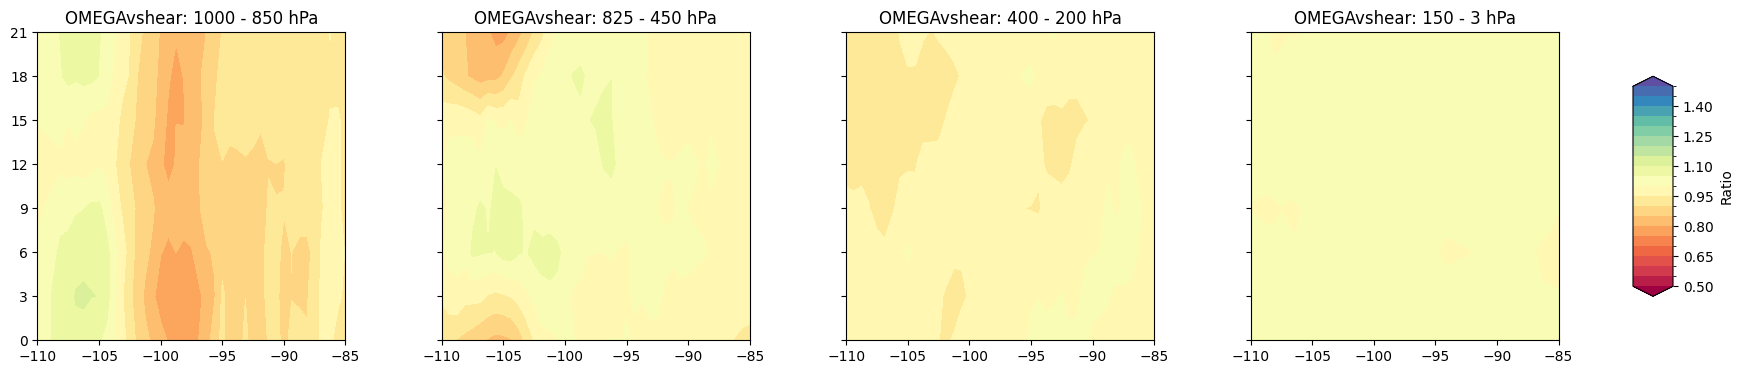

In [26]:
composite_hov = [
    lat_wtd_mean(diurnal_mean(select_great_plains_wide(da)), dim=['lat']) for da in filtered
]
ratios = [composite_hov[i] / composite_hov[-2] for i in range(len(composite_hov) - 2)]  # relative to baseline

def hovmoller(data: list[xr.Dataset]) -> plt.Figure:
    fig, axs = plt.subplots(1, len(data), sharey=True, sharex=True, figsize=(20, 4))
    xticks = np.arange(-110, -80, 5)
    yticks = np.arange(0, 24, 3)
    # vmin, vmax = 0, 6
    # levels = 13
    # bounds = np.linspace(vmin, vmax, levels)
    # cmap = cm.YlGnBu
    # extend = 'max'
    # for da, ax in zip(data[:-1], axs[:-1]):
    #     axobj = da['precip'].plot.contourf(
    #         ax=ax,
    #         vmin=vmin,
    #         vmax=vmax,
    #         levels=levels,
    #         extend=extend,
    #         cmap=cmap,
    #         add_colorbar=False
    #     )
    #     ax.set(
    #         title=da.attrs['label'],
    #         box_aspect=1,
    #         yticks=yticks,
    #         xticks=xticks,
    #         ylabel='',
    #         xlabel=''
    #     )

    for da, ax in zip(data, axs):
    ## spectral stuff for ratios
        cmap = cm.Spectral
        vmin, vmax = .5, 1.5
        levels = 21
        bounds = np.linspace(vmin, vmax, levels)
        extend = 'both'
        axobj = da['precip'].plot.contourf(
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            levels=levels,
            extend=extend,
            cmap=cmap,
            add_colorbar=False
        )
        ax.set(
            title=da.attrs['label'],
            box_aspect=1,
            yticks=yticks,
            xticks=xticks,
            ylabel='',
            xlabel=''
        )
    
    # fig.text(0.08, 0.5, 'UTC Hour', va='center', rotation='vertical', fontsize=14)
    # fig.text(0.52, 0.1, r'Longitude $^\circ$E', ha='center', fontsize=14)
    # fig.suptitle('ratio of perturbation to baseline')
    fig.subplots_adjust(right=0.9)
    cbar_ax = fig.add_axes([0.93, 0.22, 0.02, 0.55])
    cbar = fig.colorbar(
        cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(bounds, cmap.N, extend=extend), cmap=cmap),
        cax=cbar_ax,
        orientation='vertical'
    )
    cbar.set_label('Ratio', fontsize=10)
    return fig

hovmoller(ratios)

### Scaling experiments (test set data):
#### is it better to just do all of these experiments at once and save the ratios in one big plot?
#### e.g. do a 'temperature' plot with subplots that have each scaling and model performed as title for a ratio plot
#### easier to visualize than just reading these qualitative descriptions...
* PBL := LEV[:7], up to 850 hPa
* mid-level := LEV[7:13] 825 - 450 hPa
* upper-level := LEV[13:18], 400 - 200 hPa
* DOESNT REALLY SEEM LIKE ANY 'NEW' PRECIP OCCURS FROM THESE ALTHOUGH MOST DAYS PRESERVED ANYWAY (~96%) 

#### Large-scale only model:
##### Temperature:
* 10% decrease in low-level: slight general drying, strongest west of 105W
* 10% increase in low-level: strong increase over GP (largest proportional increase in late afternoon) slight drying over 105W
* 10% increase in mid-level: reduced mean precip everywhere
* 10% decrease in mid-level: general enhancement, but large increases over GP east of 105W
* 10% decrease in upper-level: minor weakening everywhere
* 10% increase in upper-level: minor strengthening everywhere
##### Meridional winds:
* 100% increase in low-level: dramatic enhancement over GP
* 50% decrease in low-level: dramatic weakening over GP, foothills maybe increase and slight reduction in prop speed.?
* 50% decrease in mid-level: minor increase over foothills, maybe slight eastward shift of peak?
* 100% increase in mid-level: definite reduction in prop speed, drying west wettening over GP tighter peak
* 100% increase in upper-level: general increase east of 105W, strongest enhancement over GP, minor weakening over foothills
* 50% decrease in upper-level: negligible changes
##### Zonal winds:
* 100% increase in mid-level: strong weakening everywhere
* 50% decrease in mid-level: strong enhancement everywhere
* 50% decrease in low-level: minor weakening over foothills, enhancement over GP
* 100% increase in low-level: enhancement over foothills, minor weakening over GP
* negligible changes for upper-level
##### Geopotential height:
* not really sure what makes sense for this... can we put in regional anomalies that arent tied to mcs.?
* maybe general increase in strength of bermuda high or NAM high?

#### Full model
##### Temperature:
* 10% decrease in low-level: strong drying over 105W, wettening over GP maybe shift in peak timing?
* 10% increase in low-level: strong enhancement around 105W, strongest proportional increases in afternoon, minor drying to the east
* 10% increase in mid-level: reduced mean precip everywhere
* 10% decrease in mid-level: strong increase over whole nocturnal peak, change in prop speed
* 10% increase in upper-level: strong increase of nocturnal peak over GP, slight drying west of 105W
* 10% decrease in upper-level: strong increase west of 105W, weak decrease over GP
##### Omega:
* 100% increase in low-level: weak general increase in precip
* 50% decrease in low-level: minor weakening of east of 100W, minor str west of 100W
* 100% increase in mid-level: increase in precip everywhere, strong increase for whole nocturnal peak
* 50% decrease in mid-level: general weakening
* 50% decrease in upper-level: general weakening
* 100% increase in upper-level: general increase, weak decrease over 105W
##### Specific humidity:
* 10% increase in low-level: wettening east of 100W, drying west of 100W
* 10% decrease in low-level: opp of above
* 10% decrease in mid-level: drying everywhere, strongest over rockies
* 10% increase in mid-level: wettening everywhere, strongest over rockies (well over 10%)
* 10% increase in upper-level: no change (100% increase shows wettening, strongest over rockies, less than 100%)
* 10% decrease in upper-level: no change (50% decrease shows weak drying everywhere)
##### Meridional winds:
* 100% increase in low-level: strong increase over GP, marginally weaker 105W and west
* 50% decrease in low-level: weak drying of nocturnal peak
* 50% decrease in mid-level: negligible change
* 100% increase in mid-level: negligible change
* 100% increase in upper-level: marginal wettening, mostly over rockies in daytime
* 50% decrease in upper-level: negligible change
##### Zonal winds:
* 50% decrease in low-level: negligible
* 100% increase in low-level: negligible
* 100% increase in mid-level: minor wettening everywhere, primarily east of 100W
* 50% decrease in mid-level: negligible
* 100% increase in upper-level: drying west of 100W, wettening east, kinda looks like eastward shift of nocturnal peak?
* 50% decrease in upper-level: kind of opp of above, 'steering winds'?
##### Geopotential height:


In [10]:
composite_line = [
    lat_wtd_mean(diurnal_mean(select_great_plains(da)), dim=['lat', 'lon']) for da in filtered
]

def line_diurnal(data: list[xr.Dataset]) -> plt.Figure:
    fig, ax = plt.subplots(layout='constrained')
    for da in data:
        da['precip'].plot.line(da.attrs['linestyle'], ax=ax, label=da.attrs['label'])
    ax.legend()
    ax.set(
        xlabel='UTC Hour',
        ylabel='Mean Precipitation (mm/day)'
    )
    return fig

line_diurnal(composite_line)

KeyError: 'linestyle'

In [ ]:
def plot_extremes(data: list[xr.Dataset]) -> plt.Figure:
    is_daily = (data[0].time[1] - data[0].time[0]).astype('timedelta64[D]') == np.timedelta64(1, 'D')
    if is_daily:
        ylabel = 'Total Daily Precipitation (mm/day)'
        f_head = 'd1'
    else:
        ylabel = 'Total 3-hourly Precipitation (mm/3h)'
        f_head = 'h3'
 
     ## 50-99.99 percentile
    percentiles = np.concat([
        np.arange(50, 91, 5),
        np.linspace(91, 99, 17),
        np.linspace(99.1, 99.9, 17),
        np.linspace(99.91, 99.99, 17)
    ])

    distrs, linestyles, labels = [], [], []
    for da in data:
        flat_da = da.to_dataarray().data.flatten()
        distrs.append(np.array([np.nanpercentile(flat_da, p) for p in percentiles]))
        linestyles.append(da.attrs['linestyle'])
        labels.append(da.attrs['label'])

    n = 5
    x_int = 1 - 1 / 10 ** np.arange(n + 2)
    ticklabs = [f'{100 * v:.2f}%' for v in x_int]
    fig, ax = plt.subplots()

    for dist, ls, l in zip(distrs, linestyles, labels):
        ax.plot(100 - percentiles, dist, ls, label=l)
    ax.invert_xaxis()
    ax.set(
        yscale='log',
        ylim=(0.1, 200),
        xscale='log',
        xlabel='Percentile of distribution',
        ylabel=ylabel
    )
    ax.xaxis.set_ticklabels(ticklabs[::-1])
    ax.legend(loc='lower right')
        
    return fig

plot_extremes([select_great_plains(da) for da in filtered])